In [1]:
import numpy as np
import matplotlib.pyplot as plt

from offline_data_gen.episode_gen import DynUnicycleEpisode
from offline_data_gen.paths import EPISODES_DIR
from offline_data_gen.ko_zones import generate_keep_out_zones

In [2]:
episode = DynUnicycleEpisode.load(EPISODES_DIR / "episode_000.npz")
print(episode)

DynUnicycleEpisode(trajectory=DynUnicycleTrajectory(t=array([0.000e+00, 1.000e-02, 2.000e-02, ..., 1.999e+01, 2.000e+01,
       2.001e+01], shape=(2002,)), x=array([[ 0.00000000e+00,  0.00000000e+00],
       [-5.21289692e-03, -2.27114285e-03],
       [-1.04187141e-02, -4.52001876e-03],
       ...,
       [-5.15015051e+00,  6.09387295e+00],
       [-5.15410044e+00,  6.09692259e+00],
       [-5.15805005e+00,  6.09996349e+00]], shape=(2002, 2)), dx=array([[-0.52164385, -0.22822885],
       [-0.52093562, -0.22600033],
       [-0.52022792, -0.22377546],
       ...,
       [-0.39500905,  0.30539985],
       [-0.39497714,  0.30452709],
       [-0.39494419,  0.30365156]], shape=(2002, 2)), ddx=array([[ 0.07085015,  0.22303443],
       [ 0.07079686,  0.22266942],
       [ 0.07074358,  0.22230442],
       ...,
       [ 0.00313959, -0.0871376 ],
       [ 0.00324334, -0.08741448],
       [ 0.00334709, -0.08769136]], shape=(2002, 2))), start=array([-0.85929246,  0.36875078,  2.1053366 ]))


In [5]:
num_zones = 8
center_pos_covar = 0.25 * np.eye(2)
center_vel_covar = 0.25 * np.eye(2)
center_acc_covar = 0.05 * np.eye(2)
radius_mean = 0.75
radius_std = 0.2
radius_vel_std = 0.1
radius_acc_std = 0.05

r = np.random.default_rng(42)
ko_zones = generate_keep_out_zones(
    episode,
    num_zones,
    center_pos_covar,
    center_vel_covar,
    center_acc_covar,
    radius_mean,
    radius_std,
    radius_vel_std,
    radius_acc_std,
    r,
)

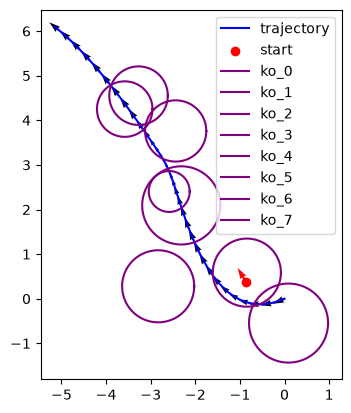

In [6]:
fig, ax = plt.subplots()
ax.plot(
    episode.trajectory.x[:, 0],
    episode.trajectory.x[:, 1],
    label="trajectory",
    color="blue",
)
ax.scatter(
    episode.start[0],
    episode.start[1],
    color="red",
    label="start",
)
ax.quiver(
    episode.start[0],
    episode.start[1],
    np.cos(episode.start[2]),
    np.sin(episode.start[2]),
    color="red",
)
idx = np.arange(0, len(episode.trajectory.t), 60)
ax.quiver(
    episode.trajectory.x[idx, 0],
    episode.trajectory.x[idx, 1],
    episode.trajectory.dx[idx, 0],
    episode.trajectory.dx[idx, 1],
    angles="xy",
    scale_units="xy",
    scale=2,
)
for i, zone in enumerate(ko_zones):
    theta = np.linspace(0, 2* np.pi, 100)
    circ_x = zone.center[0] + zone.radius * np.cos(theta)
    circ_y = zone.center[1] + zone.radius * np.sin(theta)


    ax.plot(
        circ_x, circ_y, color="purple", label=f"ko_{i}"
    )
    
ax.set_aspect('equal')
ax.legend()